<a href="https://colab.research.google.com/github/Wilmot2025/Java_Test/blob/main/Miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install transformers
!pip install gradio
!pip install pillow

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gradio as gr
from transformers import pipeline

In [4]:
import tensorflow_datasets as tfds
dataset, info = tfds.load("plant_village", with_info=True, as_supervised=True)
class_names = info.features['label'].names
num_classes = len(class_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.OGJJ8N_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


In [6]:
# Define the model architecture with updated input shape
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 1. Prepare the datasets with the new resolution
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000
total_examples = info.splits['train'].num_examples
num_val_samples = int(0.2 * total_examples)

train_ds = (dataset['train'].skip(num_val_samples)
            .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(SHUFFLE_BUFFER)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (dataset['train'].take(num_val_samples)
          .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

# 2. Run the training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

print("Training completed successfully.")

NameError: name 'class_weights' is not defined

In [ ]:
# 1. Re-initialize the data pipelines with the new 128x128 resolution
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000
total_examples = info.splits['train'].num_examples
num_val_samples = int(0.2 * total_examples)

train_ds = (dataset['train'].skip(num_val_samples)
            .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(SHUFFLE_BUFFER)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (dataset['train'].take(num_val_samples)
          .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

# 2. Train the model
print("Starting training with 128x128 images and class weights...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

print("Training completed.")

Starting training with 128x128 images and class weights...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1366s 999ms/step - accuracy: 0.2402 - loss: 2.7990 - val_accuracy: 0.6645 - val_loss: 1.1587
Epoch 2/10
 451/1358 ━━━━━━━━━━━━━━━━━━━━ 14:11 938ms/step - accuracy: 0.5537 - loss: 1.5011

In [11]:
import collections
import numpy as np

# 1. Recalculate label counts
label_counts = collections.Counter()
print("Recounting labels in the dataset...")
for _, label in dataset['train']:
    label_counts[label.numpy()] += 1

# 2. Calculate total samples and class count
total_samples = sum(label_counts.values())
num_classes = len(class_names)

# 3. Re-calculate class weights
class_weights = {}
for i in range(num_classes):
    count = label_counts[i]
    if count > 0:
        class_weights[i] = total_samples / (num_classes * count)
    else:
        class_weights[i] = 1.0

print(f"Success: Class weights for {num_classes} classes calculated.")

Recounting labels in the dataset...
Success: Class weights for 38 classes calculated.


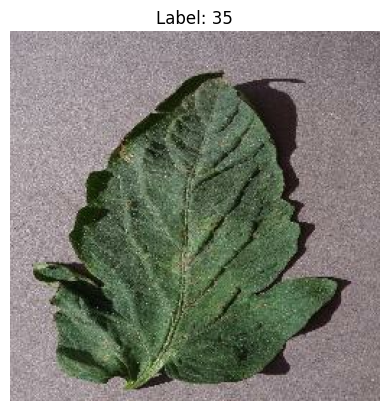

Class name for label 35: Tomato___Target_Spot


In [6]:
import matplotlib.pyplot as plt

# Take one sample from the dataset
for image, label in dataset['train'].take(1):
    plt.imshow(image.numpy())
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    plt.show()

# To see the actual class name
class_names = info.features['label'].names
print(f"Class name for label {label.numpy()}: {class_names[label.numpy()]}")

In [5]:
display(info)

tfds.core.DatasetInfo(
    name='plant_village',
    full_name='plant_village/1.0.2',
    description="""
    The PlantVillage dataset consists of 54303 healthy and unhealthy leaf images
    divided into 38 categories by species and disease.
    
    NOTE: The original dataset is not available from the original source
    (plantvillage.org), therefore we get the unaugmented dataset from a paper that
    used that dataset and republished it. Moreover, we dropped images with
    Background_without_leaves label, because these were not present in the original
    dataset.
    
    Original paper URL: https://arxiv.org/abs/1511.08060 Dataset URL:
    https://data.mendeley.com/datasets/tywbtsjrjv/1
    """,
    homepage='https://arxiv.org/abs/1511.08060',
    data_dir='/root/tensorflow_datasets/plant_village/1.0.2',
    file_format=tfrecord,
    download_size=827.82 MiB,
    dataset_size=815.37 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
     

# Task
Analyze the class distribution of the "plant_village" dataset by calculating the number of images per class in the training split. Visualize these findings using a bar chart with the appropriate class names from the dataset metadata and summarize any significant class imbalances.

## Calculate Class Distribution

### Subtask:
Iterate through the 'train' split of the 'plant_village' dataset to count the number of images associated with each class label.


**Reasoning**:
I will calculate the class distribution by iterating through the training dataset and counting the occurrences of each label, ensuring the counts are stored and verified against the dataset metadata.



In [7]:
import collections

# 1. Initialize count storage
label_counts = collections.Counter()

# 2. & 3. Iterate through the training split to count labels
# Using .as_numpy_iterator() for faster access to labels
print("Counting labels in the training set...")
for _, label in dataset['train']:
    label_counts[label.numpy()] += 1

# 4. Verify total count against info object
total_calculated = sum(label_counts.values())
total_expected = info.splits['train'].num_examples

print(f"Total images counted: {total_calculated}")
print(f"Total images expected: {total_expected}")

if total_calculated == total_expected:
    print("Verification Successful: Counts match metadata.")
else:
    print("Verification Failed: Counts do not match metadata.")

# 5. Print resulting counts for verification
# Mapping numeric labels to class names for readability
class_distribution = {class_names[i]: label_counts[i] for i in range(len(class_names))}
for name, count in sorted(class_distribution.items()):
    print(f"{name}: {count}")

Counting labels in the training set...
Total images counted: 54303
Total images expected: 54303
Verification Successful: Counts match metadata.
Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry___Powdery_mildew: 1052
Cherry___healthy: 854
Corn___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn___Common_rust: 1192
Corn___Northern_Leaf_Blight: 985
Corn___healthy: 1162
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Grape___healthy: 423
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1477
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___Leaf_scorch: 1109
Strawberry___healthy: 456
Tomato___Bacterial_spot: 2127
Tomato___Early_blig

## Visualize Distribution

### Subtask:
Create a bar chart visualizing the number of images per class using the calculated distribution data.


**Reasoning**:
I will create a bar chart to visualize the class distribution using the `class_distribution` dictionary, ensuring readability by rotating labels and setting appropriate plot titles.



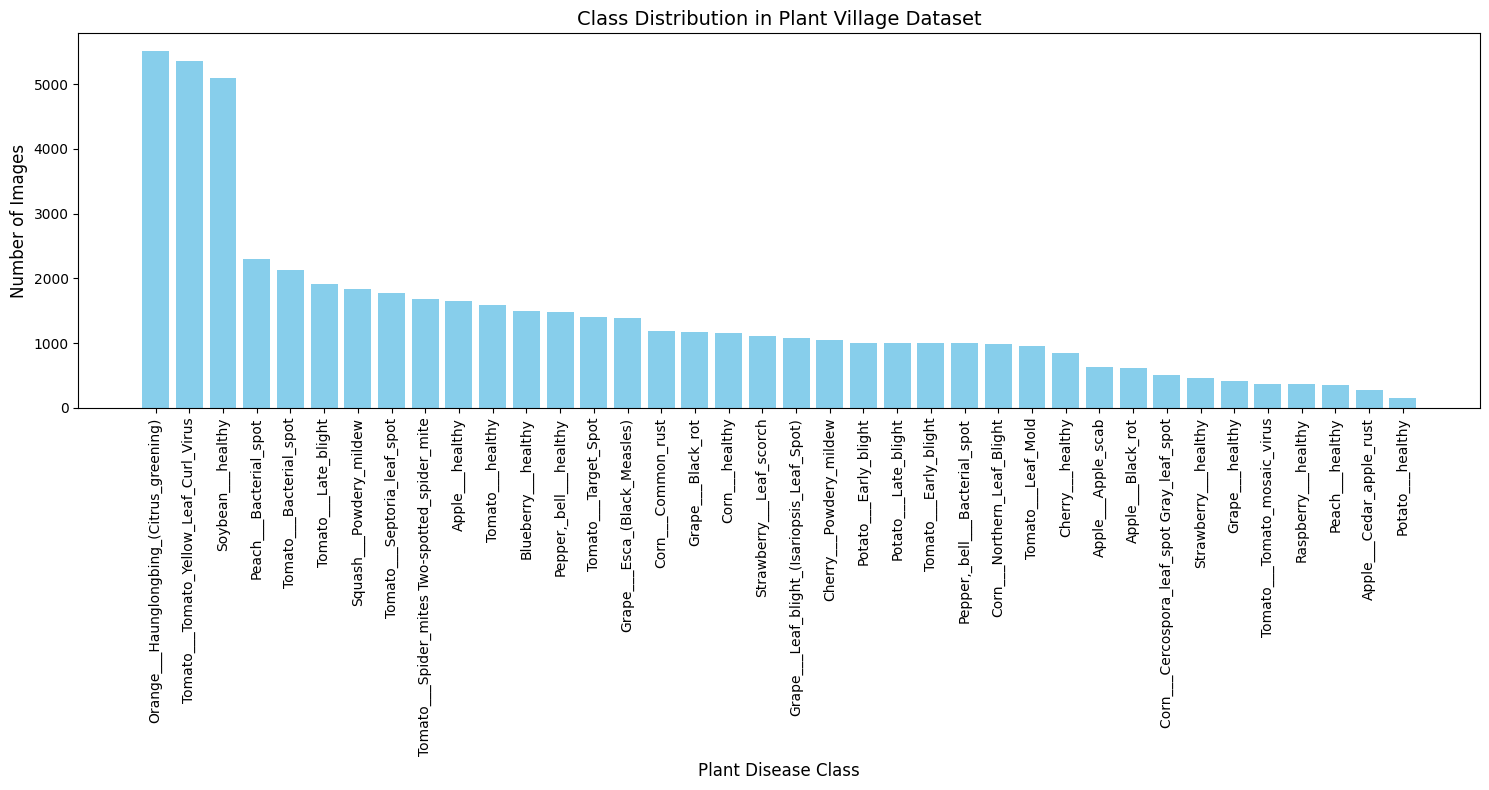

In [8]:
# Sort the distribution for better visualization
sorted_distribution = dict(sorted(class_distribution.items(), key=lambda item: item[1], reverse=True))

# Extract names and counts
names = list(sorted_distribution.keys())
counts = list(sorted_distribution.values())

# Create the bar chart
plt.figure(figsize=(15, 8))
plt.bar(names, counts, color='skyblue')

# Add labels and title
plt.xlabel('Plant Disease Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in Plant Village Dataset', fontsize=14)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

In [5]:
def preprocess_image(image, label):
    # Resize to 128x128 for faster training
    image = tf.image.resize(image, (128, 128))
    # Normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Verification check
for raw_image, raw_label in dataset['train'].take(1):
    proc_image, proc_label = preprocess_image(raw_image, raw_label)
    print(f"New Processed shape: {proc_image.shape}")
    assert proc_image.shape == (128, 128, 3), "Shape update failed!"

New Processed shape: (128, 128, 3)


In [12]:
# 1. Define buffer and batch sizes
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

# 2. Calculate validation split size (20%)
total_examples = info.splits['train'].num_examples
num_val_samples = int(0.2 * total_examples)

# 3. Create subsets
raw_train_ds = dataset['train'].skip(num_val_samples)
raw_val_ds = dataset['train'].take(num_val_samples)

# 4, 5, 6, 7. Map preprocessing, shuffle, batch, and prefetch
train_ds = (raw_train_ds
            .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(SHUFFLE_BUFFER)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (raw_val_ds
          .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

# 8. Verify the pipeline configuration
for image_batch, label_batch in train_ds.take(1):
    print(f"Batch Image Shape: {image_batch.shape}")
    print(f"Batch Label Shape: {label_batch.shape}")
    print(f"Label batch values: {label_batch.numpy()}")

print(f"\nTraining set size: {total_examples - num_val_samples} examples")
print(f"Validation set size: {num_val_samples} examples")

Batch Image Shape: (32, 224, 224, 3)
Batch Label Shape: (32,)
Label batch values: [26 14 11 12 25  3 30 22 15 29  8 25 15  9 29 15  9 37 37 29 33 15 12 37
 33 11 15 24  1 37 31  4]

Training set size: 43443 examples
Validation set size: 10860 examples


## Train Model

### Subtask:
Train the defined CNN model on the prepared datasets using class weights to account for imbalance.


**Reasoning**:
I will train the CNN model using the prepared training and validation datasets for 10 epochs while applying the calculated class weights to address the dataset imbalance.



In [ ]:
# Train the model with class weights to handle imbalance
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

print("Training completed.")

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 5009s 4s/step - accuracy: 0.2256 - loss: 2.8806 - val_accuracy: 0.7141 - val_loss: 0.9882
Epoch 2/10
 363/1358 ━━━━━━━━━━━━━━━━━━━━ 55:09 3s/step - accuracy: 0.5638 - loss: 1.4413

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

print("Training completed.")

NameError: name 'history' is not defined

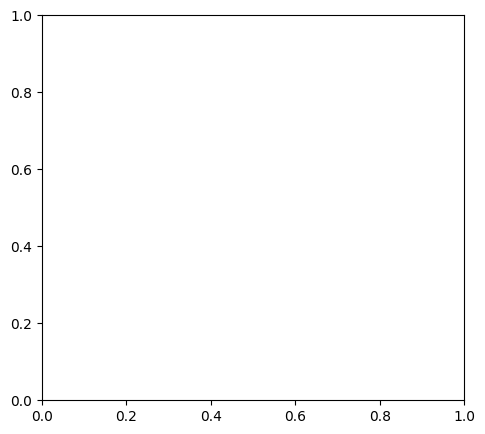

In [2]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'][:5], label='Train Accuracy')
plt.plot(history.history['val_accuracy'][:5], label='Val Accuracy')
plt.title('Accuracy over 5 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'][:5], label='Train Loss')
plt.plot(history.history['val_loss'][:5], label='Val Loss')
plt.title('Loss over 5 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [3]:
import matplotlib.pyplot as plt

# This cell will only work once the training fit() method completes
if 'history' in globals():
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('Training is still in progress. Please wait for the training cell to finish before running this.')

Training is still in progress. Please wait for the training cell to finish before running this.
